In [ ]:
from google.colab import files
files.upload()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as opt
import torch.nn.functional as func
import pandas as pd
import numpy as np

# 데이터 로드 및 전처리
file_path = '머신러닝 전력수요 예측 데이터.csv'
df = pd.read_csv(file_path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')] # 불필요한 열 제거
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df = df.dropna() # 결측치 제거

# Train/Test 분할 (Train: ~2023, Test: 2024)
train_df = df[df['Date'].dt.year <= 2023]
test_df = df[df['Date'].dt.year == 2024]

X_cols = ['X_Temp', 'X_Capdex', 'X_CapUtildex', 'X_House', 'X_IT']
y_col = 'Y_Total'

x_data = train_df[X_cols].values
y_data = train_df[y_col].values

# Min-Max 스케일링 적용
x_min, x_max = x_data.min(axis=0), x_data.max(axis=0)
y_min, y_max = y_data.min(axis=0), y_data.max(axis=0)

x_data_scaled = (x_data - x_min) / (x_max - x_min)
y_data_scaled = (y_data - y_min) / (y_max - y_min)

# Tensor 변환
x_train = torch.FloatTensor(x_data_scaled)
y_train = torch.FloatTensor(y_data_scaled).view(-1, 1)

# 다중 선형 회귀 모델 설정
model = nn.Linear(5, 1)

# Optimizer 설정
optimizer = opt.Adam(model.parameters(), lr=0.001)

print(f"[ Train Data Size: {len(train_df)} ]")
# 모델 학습
for epoch in range(5000):
    y_hypo = model(x_train)
    cost = func.mse_loss(y_hypo, y_train)

    # 파라미터 업데이트
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 진행 상황 출력
    if epoch % 500 == 499:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(epoch+1, 5000, cost.item()))

print("\n[ Model Training Completed ]")

print("\n[ 2024 Test Data Prediction Results ]")

# 테스트 데이터 분리 및 스케일링 (Train 데이터의 min/max 활용)
x_test_data = test_df[X_cols].values
y_test_data = test_df[y_col].values

x_test_scaled = (x_test_data - x_min) / (x_max - x_min)
x_test_tensor = torch.FloatTensor(x_test_scaled)

# 모델 평가 모드 전환 및 예측
model.eval()
with torch.no_grad():
    y_test_pred = model(x_test_tensor)

# 스케일링 역변환
test_predicted_scaled = y_test_pred.numpy()
test_predicted_real = test_predicted_scaled * (y_max - y_min) + y_min

# 결과 및 오차율 출력
for i in range(len(test_df)):
    month = test_df['Date'].iloc[i].strftime('%Y-%m')
    pred_val = test_predicted_real[i][0]
    actual_val = y_test_data[i]

    error_rate = abs(pred_val - actual_val) / actual_val * 100

    print(f"[{month}] Predict: {pred_val:,.0f} / Actual: {actual_val:,.0f} (Error: {error_rate:.1f}%)")

[ Train Data Size: 256 ]
Epoch  500/5000 Cost: 0.001326
Epoch 1000/5000 Cost: 0.000549
Epoch 1500/5000 Cost: 0.000468
Epoch 2000/5000 Cost: 0.000457
Epoch 2500/5000 Cost: 0.000456
Epoch 3000/5000 Cost: 0.000456
Epoch 3500/5000 Cost: 0.000456
Epoch 4000/5000 Cost: 0.000456
Epoch 4500/5000 Cost: 0.000456
Epoch 5000/5000 Cost: 0.000456

[ Model Training Completed ]

[ 2024 Test Data Prediction Results ]
[2024-01] Predict: 48,884,926 / Actual: 49,630,014 (Error: 1.5%)
[2024-02] Predict: 46,668,854 / Actual: 46,697,821 (Error: 0.1%)
[2024-03] Predict: 44,665,831 / Actual: 45,368,404 (Error: 1.5%)
[2024-04] Predict: 42,924,251 / Actual: 42,771,101 (Error: 0.4%)
[2024-05] Predict: 41,445,455 / Actual: 41,200,280 (Error: 0.6%)
[2024-06] Predict: 43,667,471 / Actual: 42,815,600 (Error: 2.0%)
[2024-07] Predict: 46,609,358 / Actual: 47,096,107 (Error: 1.0%)
[2024-08] Predict: 50,361,139 / Actual: 52,419,907 (Error: 3.9%)
[2024-09] Predict: 48,657,410 / Actual: 50,383,622 (Error: 3.4%)
[2024-10] P


[ 2024년 데이터 실전 예측 결과 (단위: GWh) ]
[2024-01] 예측값: 48,885 / 실제값: 49,630 (오차율: 1.5%)
[2024-02] 예측값: 46,669 / 실제값: 46,698 (오차율: 0.1%)
[2024-03] 예측값: 44,666 / 실제값: 45,368 (오차율: 1.5%)
[2024-04] 예측값: 42,924 / 실제값: 42,771 (오차율: 0.4%)
[2024-05] 예측값: 41,445 / 실제값: 41,200 (오차율: 0.6%)
[2024-06] 예측값: 43,667 / 실제값: 42,816 (오차율: 2.0%)
[2024-07] 예측값: 46,609 / 실제값: 47,096 (오차율: 1.0%)
[2024-08] 예측값: 50,361 / 실제값: 52,420 (오차율: 3.9%)
[2024-09] 예측값: 48,657 / 실제값: 50,384 (오차율: 3.4%)
[2024-10] 예측값: 43,436 / 실제값: 44,090 (오차율: 1.5%)
[2024-11] 예측값: 42,160 / 실제값: 41,930 (오차율: 0.5%)
[2024-12] 예측값: 45,841 / 실제값: 45,417 (오차율: 0.9%)


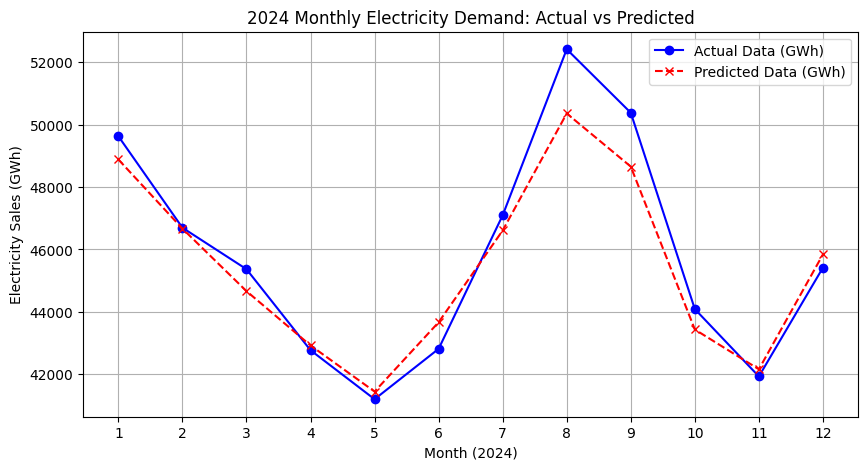

In [ ]:
import matplotlib.pyplot as plt
import torch

print("\n[ 2024년 데이터 실전 예측 결과 (단위: GWh) ]")

# 1. 2024년 데이터(test_df) 분리
x_test_data = test_df[X_cols].values
y_test_data = test_df[y_col].values

# 2. 테스트 데이터 스케일링
x_test_scaled = (x_test_data - x_min) / (x_max - x_min)

# 3. Tensor 변환
x_test_tensor = torch.FloatTensor(x_test_scaled)

# 4. 2024년 전력량 예측
model.eval()
with torch.no_grad():
    y_test_pred = model(x_test_tensor)

# 5. 스케일링 역변환 (원래 MWh 단위로 복구)
test_predicted_scaled = y_test_pred.numpy()
test_predicted_real = test_predicted_scaled * (y_max - y_min) + y_min

# 6. 월별 결과 출력 (MWh를 1,000으로 나누어 GWh로 표시)
for i in range(len(test_df)):
    month = test_df['Date'].iloc[i].strftime('%Y-%m')
    pred_val_gwh = test_predicted_real[i][0] / 1000  # GWh 변환
    actual_val_gwh = y_test_data[i] / 1000           # GWh 변환

    error_rate = abs(pred_val_gwh - actual_val_gwh) / actual_val_gwh * 100
    print(f"[{month}] 예측값: {pred_val_gwh:,.0f} / 실제값: {actual_val_gwh:,.0f} (오차율: {error_rate:.1f}%)")

# 7. 결과 시각화 (Y축 데이터를 1,000으로 나누어 적용)
plt.figure(figsize=(10, 5))

# 실제값 (파란색 실선, /1000 적용)
plt.plot(test_df['Date'].dt.month, y_test_data / 1000, marker='o', label='Actual Data (GWh)', color='blue')

# 예측값 (빨간색 점선, /1000 적용)
plt.plot(test_df['Date'].dt.month, test_predicted_real / 1000, marker='x', linestyle='--', label='Predicted Data (GWh)', color='red')

plt.title('2024 Monthly Electricity Demand: Actual vs Predicted')
plt.xlabel('Month (2024)')
plt.ylabel('Electricity Sales (GWh)') # 단위를 GWh로 명시
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import r2_score

# 1. 기존 결정계수(R2) 계산
r2 = r2_score(y_test_data, test_predicted_real)

# 2. 데이터 개수(n)와 변수 개수(k) 파악
n = len(y_test_data)       # 테스트 데이터 개수 (2024년 1월~12월 = 12개)
k = x_test_data.shape[1]   # X 변수의 개수 (현재 5개 사용 중)

# 3. 수정된 결정계수(Adjusted R2) 계산
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print("\n[ 최종 모델 성능 평가 ]")
print(f"기존 R2 Score:       {r2:.4f}")
print(f"수정된 R2 Score:     {adj_r2:.4f}")


[ 최종 모델 성능 평가 ]
기존 R2 Score:       0.9285
수정된 R2 Score:     0.8689
